## Cloudy or sunny

We need to define how we compute the next state according to the transition probabilities T and then use this to run the Markov chain

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import astroML.stats
import astropy.visualization.hist


def next_state(currentstate):
    return np.random.choice(list(T[currentstate].keys()),p=list(T[currentstate].values()))

def run_chain(initstate, iterations):
    currentstate = initstate
    chain = [currentstate]
    for _ in range(iterations-1):
         currentstate = next_state(currentstate)
         chain.append(currentstate)
    return np.array(chain)

T = {'Cloudy':{'Cloudy':0.5,'Clear':0.5},'Clear':{'Clear':0.9,'Cloudy':0.1}}
Ndays = 100000
Burn = 2000
InitialWeather = 'Cloudy'

Start with cloudy day

In [2]:
Chain = run_chain(InitialWeather,Ndays)

Now plot the trace

Text(0.5, 1.0, 'Trace over Days of p(Clear) estimate')

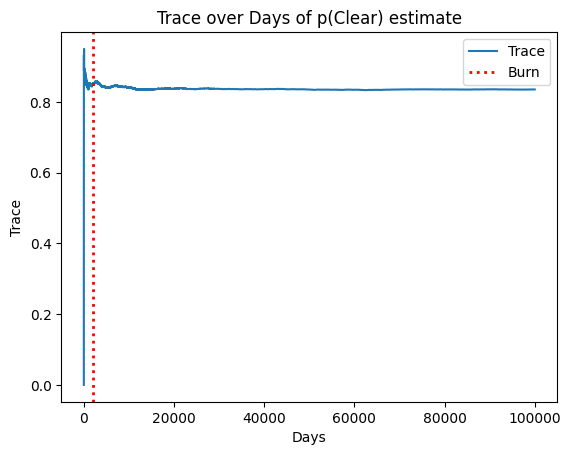

In [3]:
Days = list(range(1,Ndays+1))
IsClearDays = Chain=='Clear'
Trace = np.cumsum(IsClearDays)/Days
plt.plot(Days, Trace, label = 'Trace')
plt.axvline(x=Burn, color='red', linestyle=':', linewidth=2, label = 'Burn')
plt.xlabel('Days')           
plt.ylabel('Trace') 
plt.legend()         
plt.title('Trace over Days of p(Clear) estimate')

The trace for the probability of a clear day eventually reaches a stationary state. Plot the histogram without burn of the samples: there is wide spread in the values.

Values with 0 samples burned
Median 0.8357059072827375
Mean 0.8369412627803408
Sigma_Mean 1.7315117251031634e-05
SigmaG 0.0011662621239080322
Min/Max 0.0 0.95


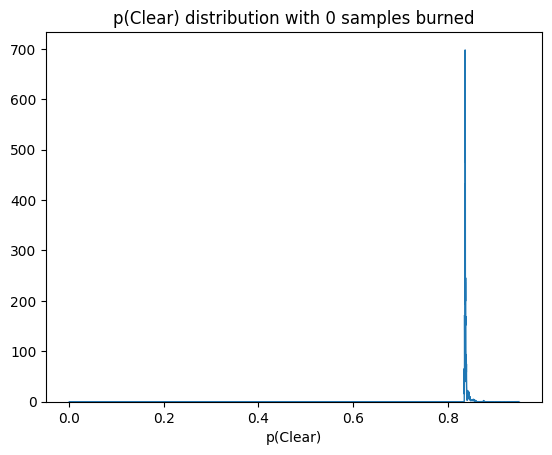

In [10]:
def plot_hist(Burn):
    plt.figure()
    astropy.visualization.hist(Trace[Burn:], bins="freedman", histtype="step",density=True, label = 'Freedman')
    #plt.hist(Trace[Burn:],bins = np.append(np.sort(Trace[Burn:])[::100], np.max(Trace[Burn:])), density=True, histtype='step')
    plt.xlabel('p(Clear)')  
    plt.title(f'p(Clear) distribution with {Burn} samples burned')

    print(f'Values with {Burn} samples burned')
    print('Median',np.median(Trace[Burn:]))
    print('Mean',np.mean(Trace[Burn:]))
    print('Sigma_Mean',np.std(Trace[Burn:])/np.sqrt(len(Trace[Burn:])))
    print('SigmaG', astroML.stats.sigmaG(Trace[Burn:]))
    print('Min/Max', min(Trace[Burn:]),max(Trace[Burn:]))
    
plot_hist(0)

With burned samples the range of the distribution reduces.

Values with 2000 samples burned
Median 0.835684314516661
Mean 0.8365871083416956
Sigma_Mean 9.992407554715865e-06
SigmaG 0.001107203237578564
Min/Max 0.8334806860743622 0.8589830508474576


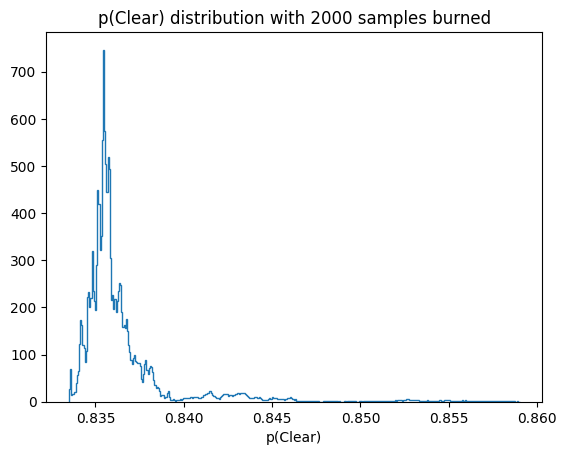

In [11]:
plot_hist(Burn)

For the uncertainty on the median, one could repeat the experiment many times and plot the distribution of the median and compute the sigma of this ditribution